# Posterior distribution and limit to thawing

### Part (i): visualize

In [17]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import torch
import scipy
import sys
import os
import xarray as xr
sys.path.append('../')

from src.utilities import low_high_marginal_percentile, load_ase_datasets, reverse_standardize
from src.ice import enthalpy_to_temperature
from src.plotting import Plotting

# PARAMETERS
secinyear    = 365 * 24 * 3600
nz           = 100 # 1D thermal model vertical nodes

# ---------------------------------------------------------------
# Load auxiliary data
# ---------------------------------------------------------------
aux_data = load_ase_datasets()
xs_ase, ys_ase = aux_data['coords']['xs'], aux_data['coords']['ys']
print("Keys of the auxiliary data dictionary:", aux_data.keys())

nx, ny = aux_data['coords']['X'].shape

# ---------------------------------------------------------------
# INPUT DATA - BASAL ENTHALPY AND GHF 
# ---------------------------------------------------------------
posterior_sample_name = "samples/hmc_md_beta3_betaw0.01.pt.npy"
H_filename       = 'H_gridded.mat'
Eb_mean_filename = 'trainingAll_Eb_sim_mean.mat' # for reverse standardization
Eb_std_filename  = 'trainingAll_Eb_sim_std.mat'
# ---------------------------------------------------------------
# ---------------------------------------------------------------

data_path        = os.getenv('RAW_DATA_PATH')
param_path       = os.getenv('PARAM_PATH')
inference_path   = os.getenv('INFERENCE_READY_DATA_PATH')
posterior_path   = os.getenv('POSTERIOR_PATH')
folder = data_path

# LOADING
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]

posterior_sample_path = os.path.join(posterior_path, posterior_sample_name)
GHF_sample_path       = os.path.join(posterior_path, "../GHF/inferred-GHF.npy")

GHF_samples           = np.load(GHF_sample_path)
posterior_samples     = np.load(posterior_sample_path)
num_Eb_samples        = posterior_samples.shape[0]
num_GHF_samples       = GHF_samples.shape[0]


  [load_ase_datasets] Loading reference coordinates …
  [load_ase_datasets] Loading Bedmap3 …
  [load_ase_datasets] Computing Tpmp …
  [load_ase_datasets] Computing surface slope …
  [load_ase_datasets] Loading velocity …
  [load_ase_datasets] Loading domain mask …
  [load_ase_datasets] Loading surface mass balance (SMB) …
  [load_ase_datasets] All datasets ready.
Keys of the auxiliary data dictionary: dict_keys(['coords', 'sdem', 'bed', 'H', 'Tpmp', 'slope_x', 'slope_y', 'slope_mag', 'vx', 'vy', 'vel', 'mask', 'domain_bound_line', 'smb'])


In [2]:
# load standardization factors for reverse standardization
Eb_mean          = scipy.io.loadmat(os.path.join(folder, Eb_mean_filename))
Eb_std           = scipy.io.loadmat(os.path.join(folder, Eb_std_filename))
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# ── Convert to temperature ─────────────────────────────────────────────
Tb_samples = np.zeros_like(posterior_samples)

for i in range(num_Eb_samples):
    Eb_i   = torch.from_numpy(posterior_samples[i])
    Tpmp_i = torch.from_numpy(aux_data['Tpmp']) if isinstance(aux_data['Tpmp'], np.ndarray) else aux_data['Tpmp']
    # reverse standardization
    Eb_i_ori = reverse_standardize(Eb_i,
                                   Eb_mean, 
                                   Eb_std, 
                                   method='relaxation',
                                   epsilon=Eb_standardize_epsilon)
    Tb_samples[i] = enthalpy_to_temperature(Eb_i_ori, Tpmp_i.ravel()).numpy()

# ── Statistics ────────────────────────────────────────────────────────
Tb_std  = np.std(Tb_samples,  axis=0).reshape(nx, ny)
Tb_mean = np.mean(Tb_samples, axis=0).reshape(nx, ny)
Tb_low, Tb_high = low_high_marginal_percentile(Tb_samples, low_percentile=5, high_percentile=95)
Tb_low  = Tb_low.reshape(nx, ny)
Tb_high = Tb_high.reshape(nx, ny)

dTpmp_mean = aux_data['Tpmp'].reshape(nx, ny) - Tb_mean
dTpmp_low  = aux_data['Tpmp'].reshape(nx, ny) - Tb_low
dTpmp_high = aux_data['Tpmp'].reshape(nx, ny) - Tb_high


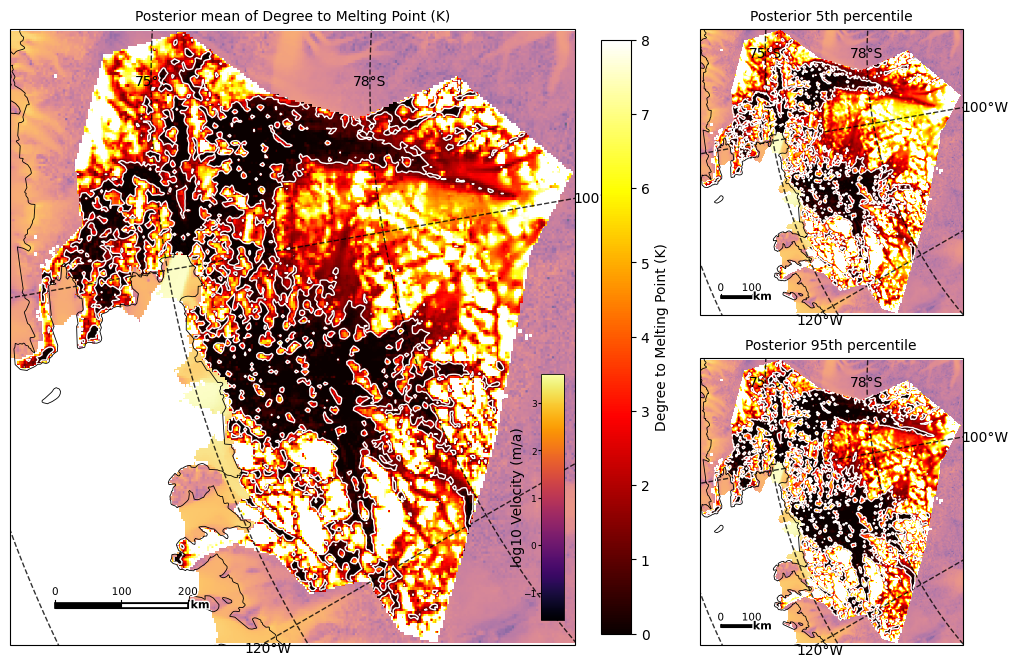

In [3]:
plotit = Plotting()
dTmax_level = 8

dTpmp_mean[aux_data['mask']==0] = np.nan
dTpmp_low[aux_data['mask']==0]  = np.nan
dTpmp_high[aux_data['mask']==0] = np.nan

posterior_mean = dict(
    x = xs_ase,
    y = ys_ase,
    data = dTpmp_mean,
    vmin = 0,
    vmax = dTmax_level,
    contour_data = dTpmp_mean, 
    contour_levels = [1],
    contour_colors = ['white'],
    cmap = 'hot',
    title = 'Posterior mean of Degree to Melting Point (K)',
    cb_label = 'Degree to Melting Point (K)',
    scalebar = (200, 2) # scale bar in km and number of segmentsbackground
)
posterior_lower = dict(
    x = xs_ase,
    y = ys_ase,
    data = dTpmp_low,
    vmin = 0,
    vmax = dTmax_level,
    cmap = 'hot',
    contour_data = dTpmp_low, 
    contour_levels = [1],
    contour_colors = ['white'],
    title = 'Posterior 5th percentile',
    colorbar = 'off',
    scalebar = (100, 1)
)
posterior_higher = dict(
    x = xs_ase,
    y = ys_ase,
    data = dTpmp_high,
    vmin = 0,
    vmax = dTmax_level,
    cmap = 'hot',
    contour_data = dTpmp_high,
    contour_levels = [1],
    contour_colors = ['white'],
    title = 'Posterior 95th percentile',
    colorbar = 'off',
    scalebar = (100, 1) 
)
background = dict(
    x = xs_ase,
    y = ys_ase,
    data = np.log10(aux_data['vel']),
    # use hillshade colormap for background
    cmap = 'inferno',
    cb_label = 'log10 Velocity (m/a)',
)

plotit.define_extent(xs_ase, ys_ase)
fig = plotit.plot(data = (posterior_mean, posterior_lower, posterior_higher), 
                  background= background,
                  layout = 'main+stack')

In [4]:
GHF_samples = GHF_samples * 1e3 # convert from W/m^2 to mW/m^2

ghf_low, ghf_high = low_high_marginal_percentile(GHF_samples, low_percentile=5, high_percentile=95)
ghf_low = ghf_low.reshape(nx, ny) 
ghf_high = ghf_high.reshape(nx, ny) 

ghf_mean = np.mean(GHF_samples, axis=0).reshape(nx, ny)

# make the same plot, but for GHF
plotit_ghf = Plotting()
ghf_max_level = 150
ghf_min_level = 50

ghf_levels = [80, 100, 120, 140]
ghf_colormap = "cividis"

ghf_mean[aux_data['mask']==0] = np.nan
ghf_low[aux_data['mask']==0]  = np.nan
ghf_high[aux_data['mask']==0] = np.nan

posterior_mean = dict(
    x = xs_ase,
    y = ys_ase,
    data = ghf_mean,
    vmin = ghf_min_level,
    vmax = ghf_max_level,
    contour_data = ghf_mean, 
    contour_levels = ghf_levels,
    contour_colors = ['white'],
    cmap = ghf_colormap,
    title = 'Posterior mean of GHF',
    cb_label = 'Geothermal Heat Flux (mW/m²)',
    scalebar = (200, 2), # scale bar in km and number of segmentsbackground
    contour_labels = True,
    contour_label_fontsize = 12
)
posterior_lower = dict(
    x = xs_ase,
    y = ys_ase,
    data = ghf_low,
    vmin = ghf_min_level,
    vmax = ghf_max_level,
    cmap = ghf_colormap,
    contour_data = ghf_low, 
    contour_levels = ghf_levels,
    contour_colors = ['white'],
    title = 'Posterior 5th percentile',
    colorbar = 'off',
    scalebar = (100, 1),
    contour_labels = True,
    contour_label_fontsize = 9
)
posterior_higher = dict(
    x = xs_ase,
    y = ys_ase,
    data = ghf_high,
    vmin = ghf_min_level,
    vmax = ghf_max_level,
    cmap = ghf_colormap,
    contour_data = ghf_high,
    contour_levels = ghf_levels,
    contour_colors = ['white'],
    title = 'Posterior 95th percentile',
    colorbar = 'off',
    scalebar = (100, 1),
    contour_labels = True,
    contour_label_fontsize = 9
)
background = dict(
    x = xs_ase,
    y = ys_ase,
    data = np.log10(aux_data['vel']),
    # use hillshade colormap for background
    cmap = 'inferno',
    cb_label = 'log10 Velocity (m/a)',
)

plotit_ghf.define_extent(xs_ase, ys_ase)


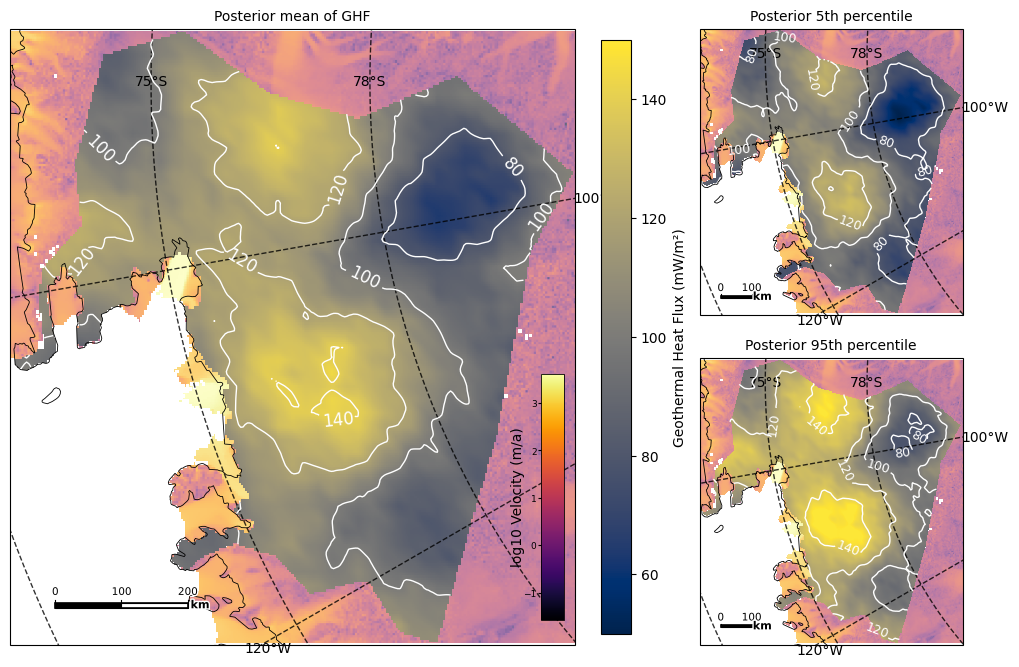

In [5]:
fig = plotit_ghf.plot(data=(posterior_mean, posterior_lower, posterior_higher),
                      background=background,
                      layout='main+stack')

### Part (ii): limit to thawing

we first find the vertical velocity at the ice surface with kinematic boundary condition and smooth the field. We apply domain cropping, biliniear interpolation on missing data, and smoothing on both the velocity field and the surface slope magnitude (to be used later). 

In [6]:
# computet the surface vertical velocity using kinematic boundary condition
# w(s) = u * ds/dx + v * ds/dy - accum_rate
# sign convention: positive w -> upward, negative w -> downward
#                  positive accumulation rate -> upward, negative accumulation rate -> downward
# (positiveaccumulation leads to downward motion)
ws = aux_data['vx'] * aux_data['slope_x'] + aux_data['vy'] * aux_data['slope_y'] - aux_data['smb']

ws_masked        = np.copy(ws)
slope_mag_masked = aux_data['slope_mag'].copy()

ws_masked[aux_data['mask']==0]        = 0 # outside the mask -> 0 
slope_mag_masked[aux_data['mask']==0] = 0 # outside the mask -> 0

# inside may still have nan, we fill with bilinear interpolation
xs_ase_defined = aux_data['coords']['X'][~np.isnan(ws_masked)]
ys_ase_defined = aux_data['coords']['Y'][~np.isnan(ws_masked)]
ws_masked_filled = scipy.interpolate.griddata(
    points=(xs_ase_defined, ys_ase_defined), 
    values=ws_masked[~np.isnan(ws_masked)], 
    xi=(aux_data['coords']['X'], aux_data['coords']['Y']),
    method='linear'
)
xs_ase_defined = aux_data['coords']['X'][~np.isnan(slope_mag_masked)]
ys_ase_defined = aux_data['coords']['Y'][~np.isnan(slope_mag_masked)]
slope_mag_masked_filled = scipy.interpolate.griddata(
    points=(xs_ase_defined, ys_ase_defined), 
    values=slope_mag_masked[~np.isnan(slope_mag_masked)], 
    xi=(aux_data['coords']['X'], aux_data['coords']['Y']),
    method='linear'
)

# gaussian smoothing
ws_smooth = scipy.ndimage.gaussian_filter(ws_masked_filled, sigma=3)
slope_mag_smooth = scipy.ndimage.gaussian_filter(slope_mag_masked_filled, sigma=3)

# mask out again
ws_masked_filled[aux_data['mask']==0] = np.nan
ws_smooth[aux_data['mask']==0]        = np.nan
slope_mag_masked_filled[aux_data['mask']==0] = np.nan
slope_mag_smooth[aux_data['mask']==0]        = np.nan

Valid pixel indices:  [  445   446   447 ... 65101 65102 65103]
Total number of valid pixels in the domain:  34091


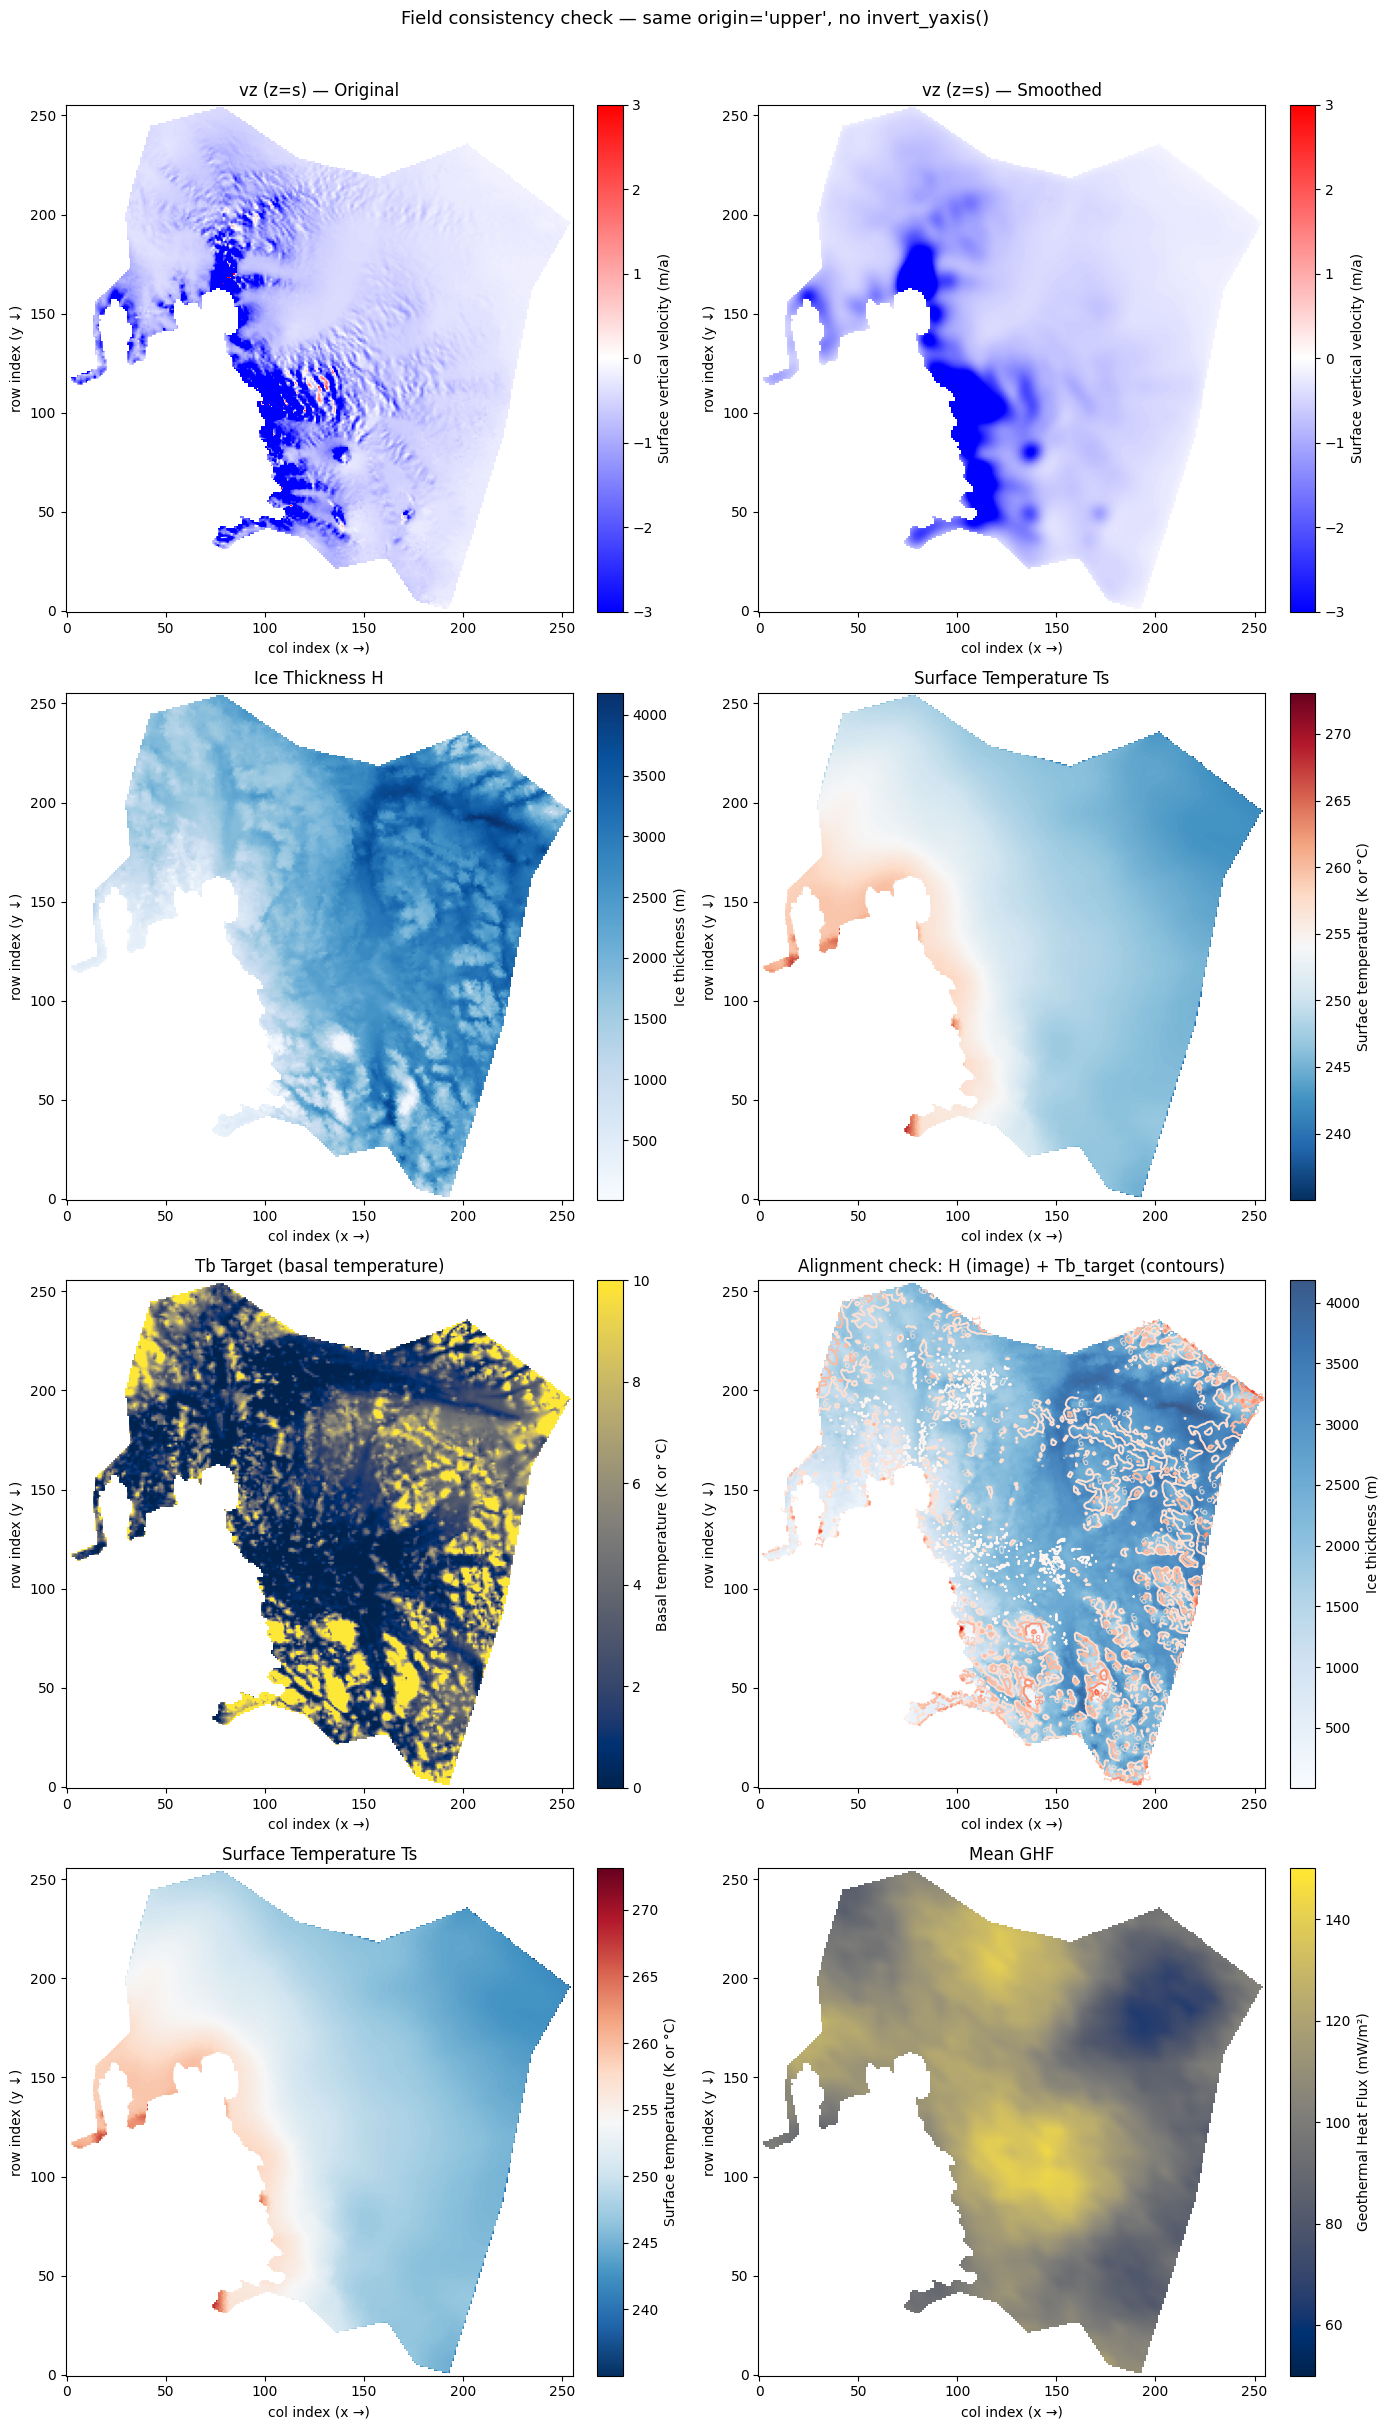

In [7]:
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# add the thermal solver
from src.iceThermalNumericalSolve import ice_thermal_numeric

# load surface temperature and depth-averaged vertical velocity from four steady state ISSM model output
# vz = scipy.io.loadmat("../data/input-time-dependent-thermal/vz-depth-averaged.mat")['vz']
Ts = scipy.io.loadmat("../data/input-time-dependent-thermal/Ts.mat")['Ts']
H  = scipy.io.loadmat("../data/input-time-dependent-thermal/H.mat")['H']
# vz_x = vz['x'][0][0]
# vz_y = vz['y'][0][0]
# vz_val = vz['mean'][0][0]
Ts_x = Ts['x'][0][0]
Ts_y = Ts['y'][0][0]
Ts_val = Ts['val'][0][0]
H_x = H['x'][0][0]
H_y = H['y'][0][0]
H_val = H['val'][0][0]

# interpolate the scattered val to our grid
# vz_grid = griddata((vz_x.flatten(), vz_y.flatten()), vz_val.flatten(), (aux_data['coords']['X'], aux_data['coords']['Y']), method='nearest')
Ts_grid = griddata((Ts_x.flatten(), Ts_y.flatten()), Ts_val.flatten(), (aux_data['coords']['X'], aux_data['coords']['Y']), method='nearest')
H_grid  = griddata((H_x.flatten(), H_y.flatten()), H_val.flatten(), (aux_data['coords']['X'], aux_data['coords']['Y']), method='nearest')
# apply 2D gaussian smoothing to just vz

Ts_grid[aux_data['mask'] == 0]        = np.nan
H_grid[aux_data['mask'] == 0]         = np.nan
del Ts, H

valid_pixel = np.isfinite(dTpmp_mean)
valid_pixel_idx = np.where(valid_pixel.flatten())[0]
print("Valid pixel indices: ", valid_pixel_idx)
print("Total number of valid pixels in the domain: ", np.sum(valid_pixel))

# target bed temperature
Tb_target = dTpmp_mean.reshape(256, 256)


fig, axes = plt.subplots(4, 2, figsize=(14, 24))

# ─── Shared plot kwargs for consistency 
imshow_kw = dict(origin='upper', aspect='equal')

# ─── Row 0: Vertical velocity at surface (before / after smoothing) ─────────────────────
im0 = axes[0, 0].imshow(ws_masked_filled, cmap='bwr', vmin=-3, vmax=3, **imshow_kw)
axes[0, 0].set_title("vz (z=s) — Original")
axes[0, 0].set_xlabel("col index (x →)")
axes[0, 0].set_ylabel("row index (y ↓)")
axes[0, 0].invert_yaxis()
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04,
             label='Surface vertical velocity (m/a)')

im1 = axes[0, 1].imshow(ws_smooth, cmap='bwr', vmin=-3, vmax=3, **imshow_kw)
axes[0, 1].set_title("vz (z=s) — Smoothed")
axes[0, 1].set_xlabel("col index (x →)")
axes[0, 1].set_ylabel("row index (y ↓)")
axes[0, 1].invert_yaxis()
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04,
             label='Surface vertical velocity (m/a)')

# ─── Row 1: Ice thickness / Surface temperature ───────────────────────────────
im2 = axes[1, 0].imshow(H_grid, cmap='Blues', **imshow_kw)
axes[1, 0].set_title("Ice Thickness H")
axes[1, 0].set_xlabel("col index (x →)")
axes[1, 0].set_ylabel("row index (y ↓)")
axes[1, 0].invert_yaxis()
fig.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04, label='Ice thickness (m)')

im3 = axes[1, 1].imshow(Ts_grid, cmap='RdBu_r', **imshow_kw)
axes[1, 1].set_title("Surface Temperature Ts")
axes[1, 1].set_xlabel("col index (x →)")
axes[1, 1].set_ylabel("row index (y ↓)")
axes[1, 1].invert_yaxis()
fig.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04, label='Surface temperature (K or °C)')

# ─── Row 2: Basal temperature target / empty slot ────────────────────────────
im4 = axes[2, 0].imshow(Tb_target, cmap='cividis', vmin=0, vmax = 10, **imshow_kw)
axes[2, 0].set_title("Tb Target (basal temperature)")
axes[2, 0].set_xlabel("col index (x →)")
axes[2, 0].set_ylabel("row index (y ↓)")
axes[2, 0].invert_yaxis()
fig.colorbar(im4, ax=axes[2, 0], fraction=0.046, pad=0.04, label='Basal temperature (K or °C)')

# ─── Row 2 right: overlay Tb_target contour on H to cross-check alignment ────
im5 = axes[2, 1].imshow(H_grid, cmap='Blues', alpha=0.8, **imshow_kw)
cs  = axes[2, 1].contour(Tb_target, levels=8, cmap='Reds', linewidths=1.5)
axes[2, 1].clabel(cs, inline=True, fontsize=7)
axes[2, 1].set_title("Alignment check: H (image) + Tb_target (contours)")
axes[2, 1].set_xlabel("col index (x →)")
axes[2, 1].set_ylabel("row index (y ↓)")
axes[2, 1].invert_yaxis()
fig.colorbar(im5, ax=axes[2, 1], fraction=0.046, pad=0.04, label='Ice thickness (m)')

# Row 3: surface temperature and mean GHF
im6 = axes[3, 0].imshow(Ts_grid, cmap='RdBu_r', **imshow_kw)
axes[3, 0].set_title("Surface Temperature Ts")
axes[3, 0].set_xlabel("col index (x →)")
axes[3, 0].set_ylabel("row index (y ↓)")    
axes[3, 0].invert_yaxis()
fig.colorbar(im6, ax=axes[3, 0], fraction=0.046, pad=0.04, label='Surface temperature (K or °C)')

# Row 3 right: mean GHF
im7 = axes[3, 1].imshow(ghf_mean, cmap='cividis', vmin=ghf_min_level, vmax=ghf_max_level, **imshow_kw)
axes[3, 1].set_title("Mean GHF")
axes[3, 1].set_xlabel("col index (x →)")
axes[3, 1].set_ylabel("row index (y ↓)")
axes[3, 1].invert_yaxis()
fig.colorbar(im7, ax=axes[3, 1], fraction=0.046, pad=0.04, label='Geothermal Heat Flux (mW/m²)')

plt.suptitle("Field consistency check — same origin='upper', no invert_yaxis()", 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [27]:
from contextlib import contextmanager


def calc_dj_vertical_vel(ws, wb, z):
    """
    Calculate vertical velocity using the Dansgaard-Johnsen formulation,
    applicable to various regimes. In the original formulation though it uses
    smb in place of ws (surface vertical vel), basal melt rate in place of wb (basal vertical vel)
    which is the negative to each other (smb = -ws, basal melt rate = -wb)

    Parameters
    ----------
    z : np.ndarray
        Height above bed (m)

    Returns
    -------
    w : np.ndarray
        Vertical velocity in m/s (converted from m/yr). Positive upward.
    """
    z = np.asarray(z, dtype=float)
    thickness = np.max(z) - np.min(z)  

    h = 0.5 * thickness  # kink height (half ice thickness)

    # a_norm is called 'k' in the original DJ formulation
    a_norm = 2 * (-ws) / (2 * thickness - h)

    w = np.zeros_like(z)

    # Boolean index masks
    lower_idx = (z >= 0) & (z <= h)
    upper_idx = (z > h)  & (z <= thickness)

    # Lower zone: 0 <= z <= h
    z_lo = z[lower_idx]
    w[lower_idx] = (
        -a_norm * z_lo**2 / (2 * h)
        - (-wb) * (1 - z_lo / thickness)
    )

    # Upper zone: h < z <= thickness
    z_up = z[upper_idx]
    w[upper_idx] = (
        -a_norm / 2 * (2 * z_up - h)
        - (-wb) * (1 - z_up / thickness)
    )

    return w

@contextmanager
def suppress_output():
    with open(os.devnull, 'w') as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        old_stdout_fd = os.dup(1)   # ← duplicate the actual file descriptor
        old_stderr_fd = os.dup(2)
        try:
            os.dup2(devnull.fileno(), 1)   # redirect fd 1 at OS level
            os.dup2(devnull.fileno(), 2)   # redirect fd 2 at OS level
            sys.stdout = devnull
            sys.stderr = devnull
            yield
        finally:
            os.dup2(old_stdout_fd, 1)      # restore fd 1
            os.dup2(old_stderr_fd, 2)      # restore fd 2
            os.close(old_stdout_fd)
            os.close(old_stderr_fd)
            sys.stdout = old_stdout
            sys.stderr = old_stderr



In [ ]:
import os
import sys
import signal
import numpy as np
from tqdm import tqdm
from scipy.optimize import brentq
import pickle
import multiprocessing as mp
from functools import partial

# ─── Helpers ──────────────────────────────────────────────────────────────────

# ─── Worker initializer ───────────────────────────────────────────────────────
# Each worker process gets its own copy of all read-only arrays.

def worker_init(shared_arrays, constants):
    global H_grid, Ts_grid, ws_smooth, ghf_model, Tb_target
    global secinyear, year_final, nz, wb_span_lo, wb_span_hi
    global WB_NARROW_LO, WB_NARROW_HI, MISFIT_TOL

    H_grid    = shared_arrays['H_grid']
    Ts_grid   = shared_arrays['Ts_grid']
    ws_smooth = shared_arrays['ws_smooth']
    ghf_model = shared_arrays['ghf_model']
    Tb_target = shared_arrays['Tb_target']

    secinyear    = constants['secinyear']
    year_final   = constants['year_final']
    nz           = constants['nz']
    wb_span_lo   = constants['wb_span_lo']
    wb_span_hi   = constants['wb_span_hi']
    WB_NARROW_LO = constants['WB_NARROW_LO']
    WB_NARROW_HI = constants['WB_NARROW_HI']
    MISFIT_TOL   = constants['MISFIT_TOL']

# ─── Per-pixel function ────────────────────────────────────────────────────────

def process_pixel_init(idx):
    h_val         = H_grid.flatten()[idx]
    Ts_val        = Ts_grid.flatten()[idx]
    ws_val        = ws_smooth.flatten()[idx]
    ghf_val       = ghf_model.flatten()[idx]
    Tb_target_val = Tb_target.flatten()[idx]

    if h_val < 50:
        return idx, np.nan, np.nan, np.nan * np.ones(nz + 1), False, 'thin_ice'

    T_md   = np.nan * np.ones(nz + 1)
    T_init = Ts_val * np.ones(nz + 1)
    z      = np.linspace(0, h_val, nz + 1)

    brackets = [
        ('narrow', WB_NARROW_LO, WB_NARROW_HI),
        ('wide',   wb_span_lo,   wb_span_hi),
    ]

    def residual(wb, warm_start=True):
        nonlocal T_init, T_md
        vz_profile = calc_dj_vertical_vel(ws_val, wb, z) / secinyear
        vz_profile = vz_profile[::-1]
        with suppress_output():
            md = ice_thermal_numeric(
                T_init, year_final, intSave=200, nz=nz, L=h_val, Tpmp=99999
            )
            md.load_advection(md.z, vz_profile, show_plot=False)
            md.apply_surface_bc(Ts_val)
            md.apply_base_bc(ghf_val)
            md.solve_steady_state(show_plot=False, tol=1e-7)
        T_md = md.T_ss[-1]
        if warm_start:
            T_init = T_md.copy()
        return float(T_md[-1]) - float(Tb_target_val)

    try:
        wb_found  = np.nan
        misfit    = np.nan
        converged = False
        status    = 'no_convergence'

        for bracket_name, wb_lo, wb_hi in brackets:

            f_lo = residual(wb_lo, warm_start=False)
            f_hi = residual(wb_hi, warm_start=False)

            if f_hi <= 0:
                wb_found, misfit, converged, status = wb_hi, f_hi, True, 'at_pmp'
                break

            if f_lo >= 0:
                if bracket_name == 'narrow':
                    continue
                else:
                    wb_found, misfit, converged, status = wb_lo, f_lo, False, 'no_convergence'
                    break

            T_init_saved = T_init.copy()

            wb_found, result = brentq(
                residual, wb_lo, wb_hi,
                xtol=1e-6, rtol=1e-6,
                full_output=True, maxiter=40
            )

            T_init = T_init_saved.copy()
            misfit = residual(wb_found, warm_start=False)
            converged = result.converged and abs(misfit) < MISFIT_TOL
            status    = f'converged_{bracket_name}' if converged else 'poor_fit'
            break

    except Exception as e:
        status    = 'error'
        converged = False
        wb_found  = np.nan
        misfit    = np.nan
        T_md      = np.nan * np.ones(nz + 1)

    return idx, misfit, wb_found, T_md, converged, status

# ─── Setup ────────────────────────────────────────────────────────────────────

secinyear    = 365 * 24 * 3600
year_final   = 100
nz           = 100
wb_span_lo   = -15.0
wb_span_hi   =  15.0
WB_NARROW_LO = -0.5
WB_NARROW_HI =  0.1
MISFIT_TOL   =  0.5

ghf_model = ghf_mean / 1e3
Tb_target = Tb_mean.reshape(256, 256)

shared_arrays = {
    'H_grid'   : H_grid,
    'Ts_grid'  : Ts_grid,
    'ws_smooth': ws_smooth,
    'ghf_model': ghf_model,
    'Tb_target': Tb_target,
}
constants = {
    'secinyear'   : secinyear,
    'year_final'  : year_final,
    'nz'          : nz,
    'wb_span_lo'  : wb_span_lo,
    'wb_span_hi'  : wb_span_hi,
    'WB_NARROW_LO': WB_NARROW_LO,
    'WB_NARROW_HI': WB_NARROW_HI,
    'MISFIT_TOL'  : MISFIT_TOL,
}

Tb_misfit        = np.nan  * np.ones(Tb_target.size)
wb_optimal       = np.nan  * np.ones(Tb_target.size)
convergence_flag = np.zeros(Tb_target.size, dtype=bool)
timeout_flag     = np.zeros(Tb_target.size, dtype=bool)
T_profile        = np.nan  * np.ones((Tb_target.size, nz + 1))

pixels_to_run = valid_pixel_idx

# ─── Config ───────────────────────────────────────────────────────────────────
RESUME          = False
CHECKPOINT_PATH = "../data/checkpoints/checkpoint_34000.pkl"
N_WORKERS       = mp.cpu_count() - 5   # leave one core free
CHUNK_SIZE      = 10                    # pixels per task batch
CHECKPOINT_EVERY = 500

if RESUME:
    with open(CHECKPOINT_PATH, "rb") as f:
        checkpoint = pickle.load(f)
    Tb_misfit        = checkpoint["Tb_misfit"]
    wb_optimal       = checkpoint["wb_optimal"]
    T_profile        = checkpoint["T_profile"]
    convergence_flag = checkpoint["convergence_flag"]
    timeout_flag     = checkpoint["timeout_flag"]
    resume_count     = checkpoint["last_count"]
    # filter out already-done pixels
    done_idx     = set(np.where(~np.isnan(wb_optimal))[0])
    pixels_to_run = np.array([i for i in pixels_to_run if i not in done_idx])
    print(f"[RESUME] {len(done_idx)} done, {len(pixels_to_run)} remaining")
else:
    resume_count = -1
    print(f"[FRESH] {len(pixels_to_run)} pixels, {N_WORKERS} workers")

# ─── Main loop ────────────────────────────────────────────────────────────────

completed = 0

with mp.Pool(
    processes=N_WORKERS,
    initializer=worker_init,
    initargs=(shared_arrays, constants)
) as pool:

    pbar = tqdm(total=len(pixels_to_run), desc="Thermal inversion", unit="px")

    for result in pool.imap_unordered(process_pixel_init, pixels_to_run, chunksize=CHUNK_SIZE):

        result_idx, misfit, wb, T_md, converged, status = result

        Tb_misfit[result_idx]        = misfit
        wb_optimal[result_idx]       = wb
        T_profile[result_idx, :]     = T_md
        convergence_flag[result_idx] = converged
        if status == 'timeout':
            timeout_flag[result_idx] = True

        completed += 1
        pbar.set_postfix({
            'idx'   : result_idx,
            'status': status,
            'wb'    : f'{wb:.2f}' if not np.isnan(wb) else 'NaN',
            'misfit': f'{misfit:.2f} K' if not np.isnan(misfit) else 'NaN',
        })
        pbar.update(1)
        pbar.refresh()

        if completed % CHECKPOINT_EVERY == 0:
            ck = {
                'Tb_misfit'       : Tb_misfit,
                'wb_optimal'      : wb_optimal,
                'T_profile'       : T_profile,
                'convergence_flag': convergence_flag,
                'timeout_flag'    : timeout_flag,
                'last_count'      : completed,
            }
            os.makedirs("../data/checkpoints/", exist_ok=True)
            with open(f'../data/checkpoints/checkpoint_{completed}.pkl', 'wb') as f:
                pickle.dump(ck, f)
            tqdm.write(f"[CHECKPOINT] Saved at count={completed}")

    pbar.close()

print("Done.", flush=True)

# ─── Save outputs ─────────────────────────────────────────────────────────────

os.makedirs("../data/output-time-dependent-thermal/", exist_ok=True)
np.save("../data/output-time-dependent-thermal/wb_optimal.npy",       wb_optimal)
np.save("../data/output-time-dependent-thermal/convergence_flag.npy", convergence_flag)
np.save("../data/output-time-dependent-thermal/timeout_flag.npy",     timeout_flag)
np.save("../data/output-time-dependent-thermal/T_profile.npy",        T_profile)
np.save("../data/output-time-dependent-thermal/Tb_misfit.npy",        Tb_misfit)


[FRESH] 34091 pixels, 19 workers


Thermal inversion:   1%|▏         | 500/34091 [02:21<2:30:41,  3.72px/s, idx=5310, status=converged_narrow, wb=-0.02, misfit=-0.00 K] 

[CHECKPOINT] Saved at count=500


Thermal inversion:   3%|▎         | 1000/34091 [04:08<2:21:26,  3.90px/s, idx=7345, status=converged_narrow, wb=0.00, misfit=-0.02 K]

[CHECKPOINT] Saved at count=1000


...

[CHECKPOINT] Saved at count=33500


Thermal inversion: 100%|█████████▉| 34011/34091 [2:09:09<00:11,  6.84px/s, idx=63552, status=converged_narrow, wb=-0.01, misfit=-0.00 K]

[CHECKPOINT] Saved at count=34000


Thermal inversion: 100%|██████████| 34091/34091 [2:09:27<00:00,  4.39px/s, idx=65102, status=converged_narrow, wb=-0.02, misfit=-0.02 K]

Done.


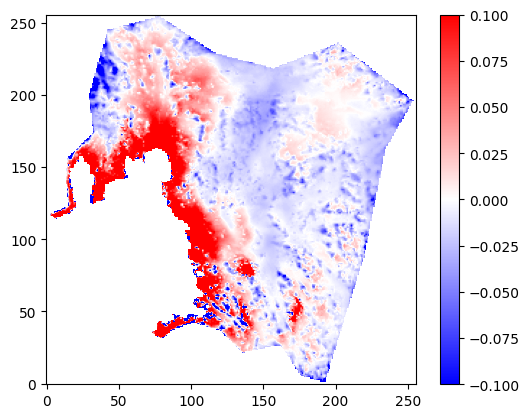

In [250]:
plt.imshow(wb_optimal.reshape(256, 256), cmap='bwr', vmin=-0.1, vmax=0.1)
plt.gca().invert_yaxis()
plt.colorbar()
plt.show()

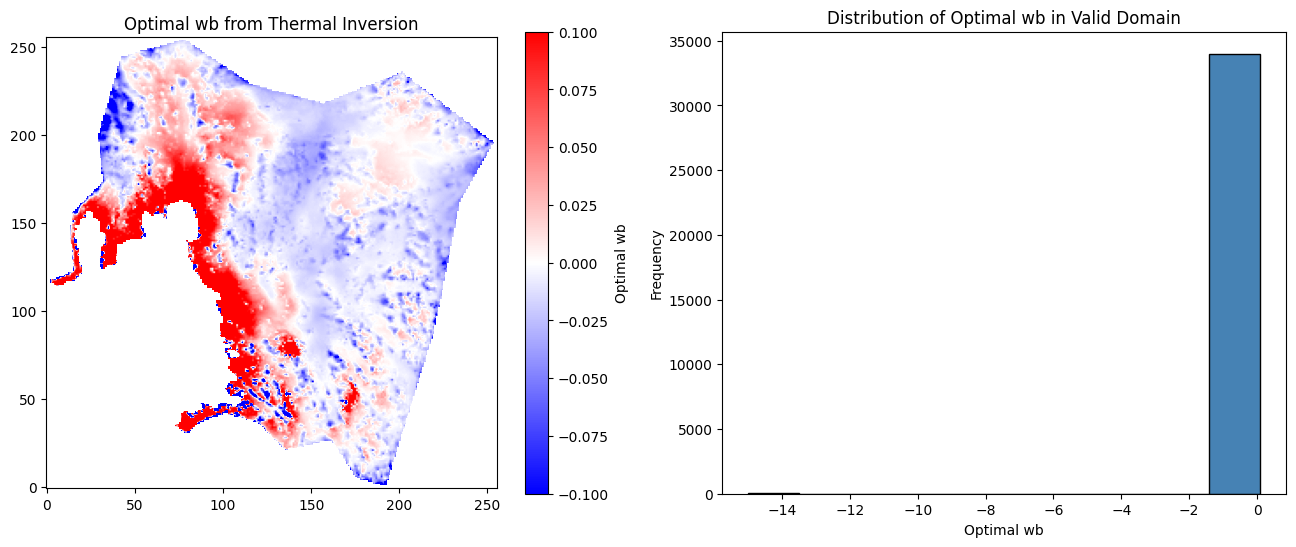

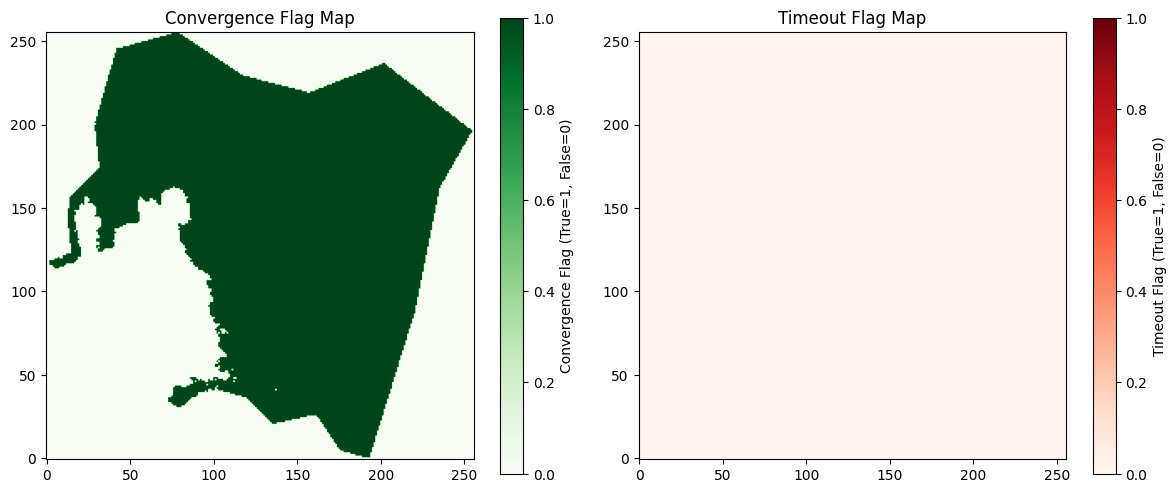

In [9]:
# load the saved data 
wb_optimal      = np.load("../data/output-time-dependent-thermal/wb_optimal.npy")
convergence_flag = np.load("../data/output-time-dependent-thermal/convergence_flag.npy")
timeout_flag     = np.load("../data/output-time-dependent-thermal/timeout_flag.npy")
T_profile        = np.load("../data/output-time-dependent-thermal/T_profile.npy")

plt.figure(figsize=(16, 6))
plt.subplot(1,2,1)
plt.imshow(wb_optimal.reshape(256, 256), cmap='bwr', vmin=-0.1, vmax=0.1)
plt.colorbar(label='Optimal wb')
plt.title("Optimal wb from Thermal Inversion")
plt.gca().invert_yaxis()
plt.subplot(1,2,2)
plt.hist(wb_optimal[valid_pixel.flatten()], color='steelblue', edgecolor='black')
plt.xlabel('Optimal wb')
plt.ylabel('Frequency')
plt.title("Distribution of Optimal wb in Valid Domain")
plt.show()
# plot convergence flag and timeout flag
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.imshow(convergence_flag.reshape(256, 256), cmap='Greens', vmin=0, vmax=1)
plt.colorbar(label='Convergence Flag (True=1, False=0)')
plt.title("Convergence Flag Map")
plt.gca().invert_yaxis()
plt.subplot(1,2,2)
plt.imshow(timeout_flag.reshape(256, 256), cmap='Reds', vmin=0, vmax=1)
plt.colorbar(label='Timeout Flag (True=1, False=0)')
plt.title("Timeout Flag Map")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

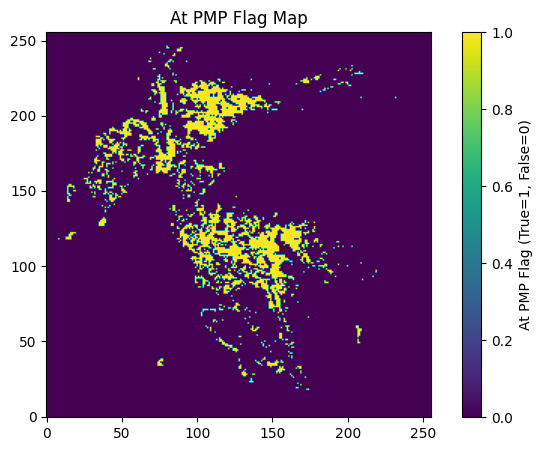

Previous total number of valid pixels in the domain:  34091
Total number of valid pixels in the domain (PMP locations excluded):  29414


In [12]:
Tb_target = Tb_mean.reshape(256, 256)

epsilon = 0.1 # degree
at_pmp_flag = np.abs(Tb_target.flatten() - aux_data["Tpmp"].flatten()) < epsilon
plt.figure(figsize=(8, 5))
plt.imshow(at_pmp_flag.reshape(256, 256), cmap='viridis')
plt.colorbar(label='At PMP Flag (True=1, False=0)')
plt.title("At PMP Flag Map")
plt.gca().invert_yaxis()
plt.show()

# recompute the total valid pixel, ignoring at pmp pixels
valid_pixel_revised = valid_pixel.flatten() & (~at_pmp_flag)
valid_pixel_revised_idx = np.where(valid_pixel_revised.flatten())[0]

print("Previous total number of valid pixels in the domain: ", np.sum(valid_pixel))
print("Total number of valid pixels in the domain (PMP locations excluded): ", np.sum(valid_pixel_revised))

#### get the surface slope (smoothed)

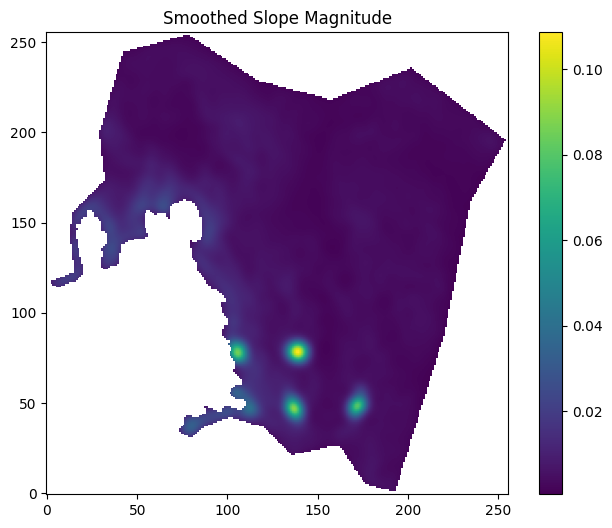

In [13]:
# # x_crop and y_crop are 1D coordinate axes — meshgrid them first
# xx_crop, yy_crop = np.meshgrid(x_crop, y_crop)  # both become (2052, 1900)

# slope = np.gradient(dem_crop, np.abs(y_crop[1] - y_crop[0]),   # row spacing (y)
#                                np.abs(x_crop[1] - x_crop[0]))  # col spacing (x)
# slope_magnitude        = np.sqrt(slope[0]**2 + slope[1]**2)
# slope_magnitude_smooth = gaussian_filter(slope_magnitude, sigma=4)

# # now all three flatten to the same length: 2052*1900
# slope_magnitude_interp = griddata(
#     (xx_crop.flatten(), yy_crop.flatten()),
#     slope_magnitude.flatten(),
#     (grid_x, grid_y),
#     method='nearest'
# )
# slope_magnitude_smooth_interp = griddata(
#     (xx_crop.flatten(), yy_crop.flatten()),
#     slope_magnitude_smooth.flatten(),
#     (grid_x, grid_y),
#     method='nearest'
# )

# slope_magnitude_interp[model_bound_data == 0]        = np.nan
# slope_magnitude_smooth_interp[model_bound_data == 0] = np.nan

plt.figure(figsize=(8,6))
plt.imshow(slope_mag_smooth, cmap='viridis')
plt.gca().invert_yaxis()
plt.title("Smoothed Slope Magnitude")
plt.colorbar()
plt.show()

#### visualize all input fields

In [14]:
# # agreement check again, adding the smoothed surface slope field
# Tb_target = posterior_samples["Tpmp"].reshape(256, 256)
# Tb_target[model_bound_data == 0] = np.nan

# fig, axes = plt.subplots(3, 2, figsize=(7, 9))

# # ─── Shared plot kwargs for consistency ───────────────────────────────────────
# imshow_kw = dict(origin='upper', aspect='equal')

# # ─── Row 0: Vertical velocity (before / after smoothing) ─────────────────────
# im0 = axes[0, 0].imshow(vz_grid, cmap='bwr', vmin=-1, vmax=1, **imshow_kw)
# axes[0, 0].set_title("vz — Original")
# axes[0, 0].set_xlabel("col index (x →)")
# axes[0, 0].set_ylabel("row index (y ↓)")
# axes[0, 0].invert_yaxis()
# fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04,
#              label='Depth-avg. vertical velocity (m/a)')

# im1 = axes[0, 1].imshow(vz_grid_smooth, cmap='bwr', vmin=-1, vmax=1, **imshow_kw)
# axes[0, 1].set_title("vz — Smoothed")
# axes[0, 1].set_xlabel("col index (x →)")
# axes[0, 1].set_ylabel("row index (y ↓)")
# axes[0, 1].invert_yaxis()
# fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04,
#              label='Depth-avg. vertical velocity (m/a)')

# # ─── Row 1: Ice thickness / Surface temperature ───────────────────────────────
# im2 = axes[1, 0].imshow(H_grid, cmap='Blues', **imshow_kw)
# axes[1, 0].set_title("Ice Thickness H")
# axes[1, 0].set_xlabel("col index (x →)")
# axes[1, 0].set_ylabel("row index (y ↓)")
# axes[1, 0].invert_yaxis()
# fig.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04, label='Ice thickness (m)')

# im3 = axes[1, 1].imshow(Ts_grid, cmap='RdBu_r', **imshow_kw)
# axes[1, 1].set_title("Surface Temperature Ts")
# axes[1, 1].set_xlabel("col index (x →)")
# axes[1, 1].set_ylabel("row index (y ↓)")
# axes[1, 1].invert_yaxis()
# fig.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04, label='Surface temperature (K or °C)')

# # ─── Row 2: Basal temperature target ────────────────────────────
# im4 = axes[2, 0].imshow(Tb_target, cmap='RdBu_r',vmin=260,vmax=274, **imshow_kw)
# axes[2, 0].set_title("Tb Target (basal temperature)")
# axes[2, 0].set_xlabel("col index (x →)")
# axes[2, 0].set_ylabel("row index (y ↓)")
# axes[2, 0].invert_yaxis()
# fig.colorbar(im4, ax=axes[2, 0], fraction=0.046, pad=0.04, label='Basal temperature (K or °C)')

# im6 = axes[2, 1].imshow(slope_magnitude_smooth_interp, cmap='terrain', vmin=0, vmax=0.1, **imshow_kw)
# axes[2, 1].set_title("Smoothed Surface Slope Magnitude")
# axes[2, 1].set_xlabel("col index (x →)")
# axes[2, 1].set_ylabel("row index (y ↓)")
# axes[2, 1].invert_yaxis()
# fig.colorbar(im6, ax=axes[2, 1], fraction=0.046, pad=0.04, label='Surface slope magnitude (after smoothing)')

# plt.suptitle("Field consistency check — same origin='upper'", 
#              fontsize=13, y=1.01)
# plt.tight_layout()
# plt.show()


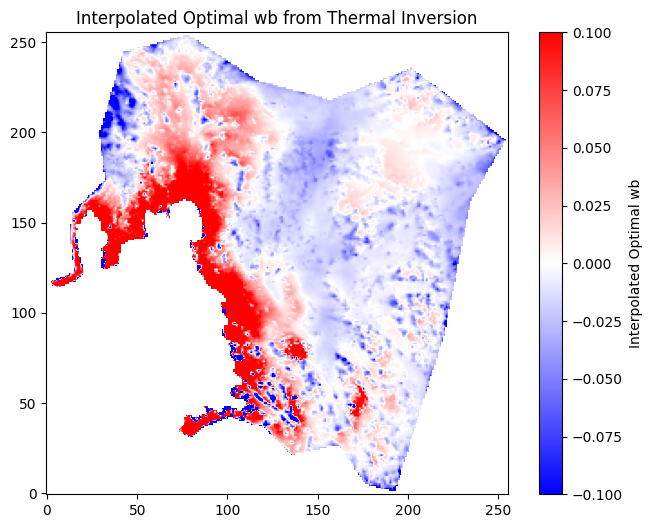

In [15]:
# inside the domain, if there is non-convergence, interpolate the wb value from neighboring pixels
wb_optimal_copy = wb_optimal.copy()
xs_ase_defined = aux_data['coords']['X'].ravel()[~np.isnan(wb_optimal_copy)]
ys_ase_defined = aux_data['coords']['Y'].ravel()[~np.isnan(wb_optimal_copy)]
wb_optimal_interp = griddata(
    points=(xs_ase_defined, ys_ase_defined),
    values=wb_optimal_copy[~np.isnan(wb_optimal_copy)],
    xi=(aux_data['coords']['X'].ravel(), aux_data['coords']['Y'].ravel()),
    method='linear'
)
wb_optimal_interp = wb_optimal_interp.reshape(256, 256)
wb_optimal_interp[aux_data['mask']==0] = np.nan

plt.figure(figsize=(8,6))
plt.imshow(wb_optimal_interp.reshape(256, 256), cmap='bwr', vmin=-0.1, vmax=0.1)
plt.colorbar(label='Interpolated Optimal wb')
plt.title("Interpolated Optimal wb from Thermal Inversion")
plt.gca().invert_yaxis()
plt.show()

In [34]:
import pickle
import os
import numpy as np
from tqdm import tqdm
from src.iceThermalNumericalSolve import ice_thermal_numeric
from concurrent.futures import ProcessPoolExecutor, as_completed


# ─── Worker initializer ───────────────────────────────────────────────────────
def init_worker(H_grid_, Ts_grid_, ws_smooth_, wb_optimal_interp_, Tb_target_,
                ghf_grid_, T_profile_,
                nz_, year_final_, secinyear_):
    global H_grid, Ts_grid, ws_smooth, wb_optimal_interp, Tb_target
    global ghf_grid, T_profile, slope_mag_smooth
    global nz, year_final, secinyear

    H_grid                        = H_grid_
    Ts_grid                       = Ts_grid_
    ws_smooth                     = ws_smooth_
    wb_optimal_interp             = wb_optimal_interp_
    Tb_target                     = Tb_target_
    ghf_grid                      = ghf_grid_
    T_profile                     = T_profile_
    nz                            = nz_
    year_final                    = year_final_
    secinyear                     = secinyear_


# ─── Per-pixel worker ─────────────────────────────────────────────────────────
def process_pixel_perturb(idx, slope_0, timeout_sec=60):
    from src.ice import strain_heating
    from scipy.optimize import brentq

    h_val         = H_grid.flatten()[idx]
    Ts_val_px     = Ts_grid.flatten()[idx]
    ws_val_px     = ws_smooth.flatten()[idx]
    wb_val_px     = wb_optimal_interp.flatten()[idx]
    Tb_target_val = Tb_target.flatten()[idx]   # this is Tpmp for this pixel
    ghf           = ghf_grid.flatten()[idx]

    if h_val < 50:
        return idx, np.nan, np.nan * np.ones(nz + 1), False, 'thin_ice'

    T_init_base = T_profile[idx, :].copy()
    z           = np.linspace(0, h_val, nz + 1)

    # precompute fixed quantities
    vz_profile = calc_dj_vertical_vel(ws_val_px, wb_val_px, z) / secinyear
    vz_profile = vz_profile[::-1]
    Q_ori      = strain_heating(slope_0, h_val, z)
    
    def residual(delta_frac, warm_start=True):
        nonlocal T_init_base
        slope_new = slope_0 * (1.0 + delta_frac)
        Q_perturb = strain_heating(slope_new, h_val, z)
        Q_diff    = (Q_perturb - Q_ori)[::-1]
        with suppress_output():
            md = ice_thermal_numeric(
                T_init_base, year_final, intSave=200, nz=nz, L=h_val, Tpmp=99999
            )
            md.load_advection(md.z, vz_profile, show_plot=False)
            md.apply_surface_bc(Ts_val_px)
            md.apply_base_bc(ghf)
            md.load_source_term(md.z, Q_diff, show_plot=False)
            md.solve_steady_state(show_plot=False)

        T_md = md.T_ss[-1]
        if warm_start:
            T_init_base = T_md.copy()

        if DEBUG_MODE:
            print(f"[DEBUG] idx={idx}, delta_frac={delta_frac:.4f}, slope_new={slope_new:.4f}, T_md[-1]={T_md[-1]:.4f}")
        return float(T_md[-1]) - float(Tb_target_val)

    try:
        # ── bracket check ─────────────────────────────────────────────────────
        # delta_frac=0: no perturbation, should be cold (f < 0)
        # delta_frac=2: 200% increase, should be hot (f > 0)
        # Use warm_start=False so bracket evals don't contaminate T_init_base
        f_lo = residual(0.0,  warm_start=False)
        f_hi = residual(slope_frac_max,  warm_start=False)

        if f_lo >= 0:
            # already at or above PMP with no perturbation
            return idx, 0.0, T_profile[idx, :], True, 'already_at_pmp'

        if f_hi <= 0:
            # even 200% slope increase can't reach PMP
            return idx, np.nan, np.nan * np.ones(nz + 1), False, 'no_crossing'

        # ── brentq search ─────────────────────────────────────────────────────
        T_init_saved = T_init_base.copy()

        delta_frac_found, result = brentq(
            residual, 0.0, slope_frac_max,
            xtol=1e-4, rtol=1e-4,
            full_output=True, maxiter=40
        )

        # ── clean final eval ──────────────────────────────────────────────────
        T_init_base = T_init_saved.copy()
        misfit      = residual(delta_frac_found, warm_start=False)
        converged   = result.converged and abs(misfit) < MISFIT_TOL
        status      = 'converged' if converged else 'poor_fit'

        # get final T profile at the critical slope
        T_md_final  = T_init_base.copy()   # residual() updated T_init_base via warm_start=False above
        # actually grab it directly:
        slope_crit  = slope_0 * (1.0 + delta_frac_found)
        Q_perturb   = strain_heating(slope_crit, h_val, z)
        Q_diff      = (Q_perturb - Q_ori)[::-1]
        # print(f"[DEBUG] idx={idx}, slope_crit={slope_crit:.4f}, misfit={misfit:.4f}")
        with suppress_output():
            md_final = ice_thermal_numeric(
                T_profile[idx, :].copy(), year_final, intSave=200, nz=nz, L=h_val, Tpmp=99999
            )
            md_final.load_advection(md_final.z, vz_profile, show_plot=False)
            md_final.apply_surface_bc(Ts_val_px)
            md_final.apply_base_bc(ghf)
            md_final.load_source_term(md_final.z, Q_diff, show_plot=False)
            md_final.solve_steady_state(show_plot=False)
        T_md_final = md_final.T_ss[-1]

        return idx, delta_frac_found, T_md_final, converged, status

    except Exception as e:
        return idx, np.nan, np.nan * np.ones(nz + 1), False, 'error'

# ------------------------------------
# ---------- PARAMETERS --------------
# ------------------------------------
DEBUG_MODE = False
if DEBUG_MODE:
    N_WORKERS = 1
else:
    N_WORKERS = 20 # my desktop has 24 cores
Tb_target = aux_data["Tpmp"].copy()
Tb_target[aux_data["mask"] == 0] = np.nan

ghf_model      = ghf_mean / 1e3
year_final     = 1e6
slope_frac_max = 5.0
MISFIT_TOL     = 0.5

# -------------------------------------


# ─── Output arrays ────────────────────────────────────────────────────────────
# just run one pixel for validation first
# randomly choose one pixel from the valid_pixel_revised_idx
valid_pixel_revised = valid_pixel.flatten() & (~at_pmp_flag)
valid_pixel_revised_idx_all = np.where(valid_pixel_revised.flatten())[0]

if DEBUG_MODE:
    valid_pixel_revised_idx = np.random.choice(valid_pixel_revised_idx_all, size=100, replace=False)
else:
    valid_pixel_revised_idx = valid_pixel_revised_idx_all

n_pixels = len(valid_pixel_revised_idx)   # ← always correct
n_pixels             = len(valid_pixel_revised_idx)
delta_slope_critical = np.full(n_pixels, np.nan) 
T_profile_critical   = np.full((n_pixels, nz + 1), np.nan)
convergence_flag     = np.zeros(n_pixels, dtype=bool)
status_arr_out       = np.empty(n_pixels, dtype=object)


# ─── Load checkpoint ──────────────────────────────────────────────────────────
CHECKPOINT_FILE = "../data/checkpoints/checkpoint_slope_0.pkl"

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, "rb") as f:
        ckpt = pickle.load(f)
    delta_slope_critical = ckpt["delta_slope_critical"]
    T_profile_critical   = ckpt["T_profile_critical"]
    convergence_flag     = ckpt["convergence_flag"]
    status_arr_out       = ckpt["status_arr_out"]
    resume_count         = ckpt["last_count"]
    print(f"[RESUME] count={resume_count}")
else:
    resume_count = -1
    print("[FRESH] Starting from scratch")


# ─── Build job list ───────────────────────────────────────────────────────────
pixels_remaining = valid_pixel_revised_idx[resume_count + 1:]

jobs = []
for count, idx in enumerate(pixels_remaining):
    slope_0      = slope_mag_smooth.flatten()[idx]
    global_count = count + resume_count + 1
    jobs.append((global_count, idx, slope_0))


# ─── Parallel execution ───────────────────────────────────────────────────────
with ProcessPoolExecutor(
    max_workers=N_WORKERS,
    initializer=init_worker,
    initargs=(H_grid, Ts_grid, ws_smooth, wb_optimal_interp, Tb_target,
              ghf_model, T_profile, #slope_mag_smooth,
              nz, year_final, secinyear)
) as executor:

    futures = {
        executor.submit(process_pixel_perturb, idx, slope_0, 60): (global_count, idx)
        for global_count, idx, slope_0 in jobs
    }


    pbar           = tqdm(as_completed(futures), total=len(futures),
                          desc="Slope perturbation", unit="px")
    completed_counts = []
    n_converged      = 0
    n_thin           = 0
    n_no_cross       = 0
    n_error          = 0
    
    for future in pbar:
        global_count, idx = futures[future]
        try:
            result_idx, delta_frac, T_md, converged, status = future.result(timeout=120)
        except Exception as e:
            tqdm.write(f"[ERROR] gc={global_count} idx={idx}: {e}")
            n_error += 1
            continue

        delta_slope_critical[global_count] = delta_frac
        T_profile_critical[global_count]   = T_md
        convergence_flag[global_count]      = converged
        status_arr_out[global_count]        = status
        completed_counts.append(global_count)

        if status   == 'thin_ice':       n_thin      += 1
        elif status == 'converged':    n_converged += 1
        elif status == 'no_crossing':  n_no_cross  += 1

        pbar.set_postfix({
            'conv'    : n_converged,
            'no_cross': n_no_cross,
            'thin'    : n_thin,
            'Δslope'  : f'{delta_frac*100:.1f}%' if not np.isnan(delta_frac) else '-',
        }, refresh=False)

        # Save checkpoint every 500 completed pixels
        if len(completed_counts) > 0 and len(completed_counts) % 1000 == 0:
            last = max(completed_counts)
            ckpt = {
                'delta_slope_critical' : delta_slope_critical,
                'T_profile_critical'   : T_profile_critical,
                'convergence_flag'     : convergence_flag,
                'status_arr_out'       : status_arr_out,
                'last_count'           : last,
            }
            with open(f'../data/checkpoints/checkpoint_slope_{last}.pkl', 'wb') as f:
                pickle.dump(ckpt, f)
            tqdm.write(f"[CKPT] {last} | conv={n_converged} thin={n_thin} err={n_error}")


pbar.close()
print(f"Done. converged={n_converged}  thin={n_thin}  errors={n_error}", flush=True)


[FRESH] Starting from scratch


Slope perturbation:   3%|▎         | 1001/29414 [05:58<2:45:16,  2.87px/s, conv=987, no_cross=14, thin=0, Δslope=11.7%]

[CKPT] 1009 | conv=986 thin=0 err=0


Slope perturbation:   7%|▋         | 2002/29414 [12:09<1:43:04,  4.43px/s, conv=1942, no_cross=53, thin=0, Δslope=158.1%]

[CKPT] 2010 | conv=1940 thin=0 err=0


...

[CKPT] 28002 | conv=27060 thin=11 err=0


Slope perturbation:  99%|█████████▊| 29000/29414 [2:56:44<01:27,  4.73px/s, conv=28038, no_cross=661, thin=11, Δslope=117.5%]

[CKPT] 29002 | conv=28038 thin=11 err=0


Slope perturbation: 100%|██████████| 29414/29414 [2:58:50<00:00,  2.74px/s, conv=28439, no_cross=674, thin=11, Δslope=195.5%]

Done. converged=28439  thin=11  errors=0


In [35]:
# ─── Save outputs ─────────────────────────────────────────────────────────────
os.makedirs("../data/output-slope-perturbation/", exist_ok=True)
# save
np.save("../data/output-slope-perturbation/delta_slope_critical.npy", delta_slope_critical)
np.save("../data/output-slope-perturbation/T_profile_critical.npy",   T_profile_critical)
np.save("../data/output-slope-perturbation/convergence_flag.npy", convergence_flag)
np.save("../data/output-slope-perturbation/status_arr_out.npy", status_arr_out)

In [42]:
from src.ice import delta_driving_stress

# map the delta_slope_critical back to the original 256x256 grid
delta_slope_critical_map = np.full(256*256, np.nan)
delta_slope_critical_map[valid_pixel_revised_idx] = delta_slope_critical
delta_slope_critical_map = delta_slope_critical_map.reshape(256, 256)

# compute the increase of the driving stress, linearized around the current ice thickness
slope_change = slope_mag_smooth.flatten() * delta_slope_critical_map.flatten()
dtaud = delta_driving_stress(slope_change, H_grid.flatten())
slope_change = slope_change.reshape(256, 256)
dtaud = dtaud.reshape(256, 256)

/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/plotting.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


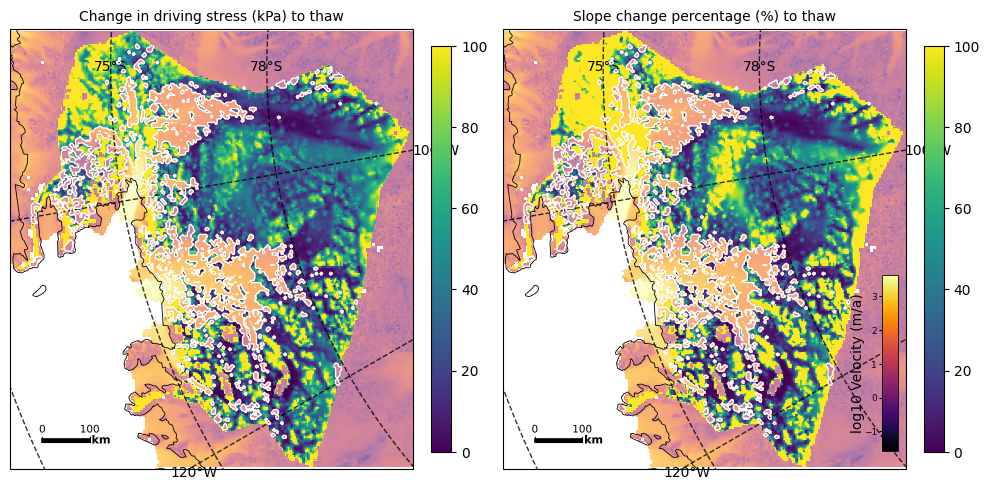

In [55]:
dtaud_plot = dict(
    x = xs_ase,
    y = ys_ase,
    data = dtaud / 1e3,  # convert to kPa
    title = 'Change in driving stress (kPa) to thaw',
    vmax = 100,
    contour_data   = at_pmp_flag.reshape(256, 256),
    contour_levels = [0.1],
    contour_colors = ['white'],
    colorbar = 'on',
    scalebar = (100, 1),
)
dslope_plot = dict(
    x = xs_ase,
    y = ys_ase,
    data = delta_slope_critical_map * 100,  # convert to percentage
    contour_data   = at_pmp_flag.reshape(256, 256),
    contour_levels = [0.1],
    contour_colors = ['white'],
    title = 'Slope change percentage (%) to thaw',
    vmax = 100,
    colorbar = 'on',
    scalebar = (100, 1),
)
background = dict(
    x = xs_ase,
    y = ys_ase,
    data = np.log10(aux_data['vel']),
    # use hillshade colormap for background
    cmap = 'inferno',
    cb_label = 'log10 Velocity (m/a)',
)

plotit_thaw = Plotting()
plotit_thaw.define_extent(xs_ase, ys_ase)
fig = plotit_thaw.plot(data=(dtaud_plot, dslope_plot),
                      background=background)
fig.savefig("../figs/perturbation_to_thaw.png", dpi=300, bbox_inches='tight')